In [25]:
# CELL 1: PROJECT SETUP
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the notebook can see the 'src' folder
sys.path.append(os.path.abspath('..'))

print("Setup Complete. Environment: Market_basket")

Setup Complete. Environment: Market_basket


In [26]:
# CELL 2: MODULAR DATA CLEANING
from src.processing import clean_grocery_data

# Load raw data and apply the professional cleaning pipeline from src/processing.py
df_raw = pd.read_csv('../data/raw/groceries.csv')
df = clean_grocery_data(df_raw).copy()

print(f"Data Audit Complete. Total Transactions: {len(df)}")

Data Audit Complete. Total Transactions: 38006


In [27]:
# CELL 3: WEB SCRAPING FOR CATEGORIZATION
from src.scraping import scrape_food_categories

# Fetch supplementary food groups from Wikipedia to enrich our dataset
scraped_data = scrape_food_categories()

def categorize_item(item):
    item = item.lower()
    if any(word in item for word in ['milk', 'yogurt', 'cream', 'cheese']): return 'Dairy'
    if any(word in item for word in ['veg', 'fruit', 'potato', 'onion']): return 'Produce'
    if any(word in item for word in ['beer', 'wine', 'liquor']): return 'Alcohol'
    if any(word in item for word in ['sausage', 'meat', 'beef', 'chicken']): return 'Meat'
    if any(word in item for word in ['bread', 'roll', 'pastry', 'bun']): return 'Bakery'
    return 'Other'

# Apply categorization using the professional .loc method
df.loc[:, 'Category'] = df['itemDescription'].apply(categorize_item)
print("Scraping and Merging Successful.")

Scraping and Merging Successful.


In [28]:
# CELL 4: ASSOCIATION RULE MINING (APRIORI)
from mlxtend.frequent_patterns import apriori, association_rules

# Encode data for Market Basket Analysis
basket = (df.groupby(['Member_number', 'itemDescription'])['itemDescription']
          .count().unstack().reset_index().fillna(0)
          .set_index('Member_number'))

def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_units)

# Generate Frequent Itemsets and Rules
frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

rules.sort_values('lift', ascending=False).head(10)

/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_27333/3780660993.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.applymap(encode_units)
/opt/miniconda3/envs/Market_basket/lib/python3.9/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
15192,"(yogurt, rolls/buns)","(whole milk, sausage, other vegetables)",0.111339,0.050282,0.013597,0.122120,2.428689,1.0,0.007998,1.081831,0.661957,0.091854,0.075641,0.196264
15177,"(whole milk, sausage, other vegetables)","(yogurt, rolls/buns)",0.050282,0.111339,0.013597,0.270408,2.428689,1.0,0.007998,1.218025,0.619400,0.091854,0.178999,0.196264
15184,"(yogurt, other vegetables, rolls/buns)","(whole milk, sausage)",0.052335,0.106978,0.013597,0.259804,2.428575,1.0,0.007998,1.206467,0.620721,0.093310,0.171133,0.193451
15185,"(whole milk, sausage)","(yogurt, other vegetables, rolls/buns)",0.106978,0.052335,0.013597,0.127098,2.428575,1.0,0.007998,1.085650,0.658702,0.093310,0.078893,0.193451
12799,"(whole milk, sausage)","(curd, yogurt)",0.106978,0.040277,0.010005,0.093525,2.322046,1.0,0.005696,1.058742,0.637549,0.072897,0.055483,0.170966
12798,"(curd, yogurt)","(whole milk, sausage)",0.040277,0.106978,0.010005,0.248408,2.322046,1.0,0.005696,1.188173,0.593239,0.072897,0.158372,0.170966
15194,"(yogurt, other vegetables)","(whole milk, sausage, rolls/buns)",0.120318,0.048743,0.013597,0.113006,2.318415,1.0,0.007732,1.072451,0.646451,0.087459,0.067556,0.195977
15175,"(whole milk, sausage, rolls/buns)","(yogurt, other vegetables)",0.048743,0.120318,0.013597,0.278947,2.318415,1.0,0.007732,1.219997,0.597810,0.087459,0.180326,0.195977
15186,"(sausage, rolls/buns)","(whole milk, yogurt, other vegetables)",0.082350,0.071832,0.013597,0.165109,2.298554,1.0,0.007681,1.111724,0.615642,0.096715,0.100496,0.177197
15183,"(whole milk, yogurt, other vegetables)","(sausage, rolls/buns)",0.071832,0.082350,0.013597,0.189286,2.298554,1.0,0.007681,1.131903,0.608665,0.096715,0.116532,0.177197


/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_27333/1853772576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='magma', order=df['Category'].value_counts().index)


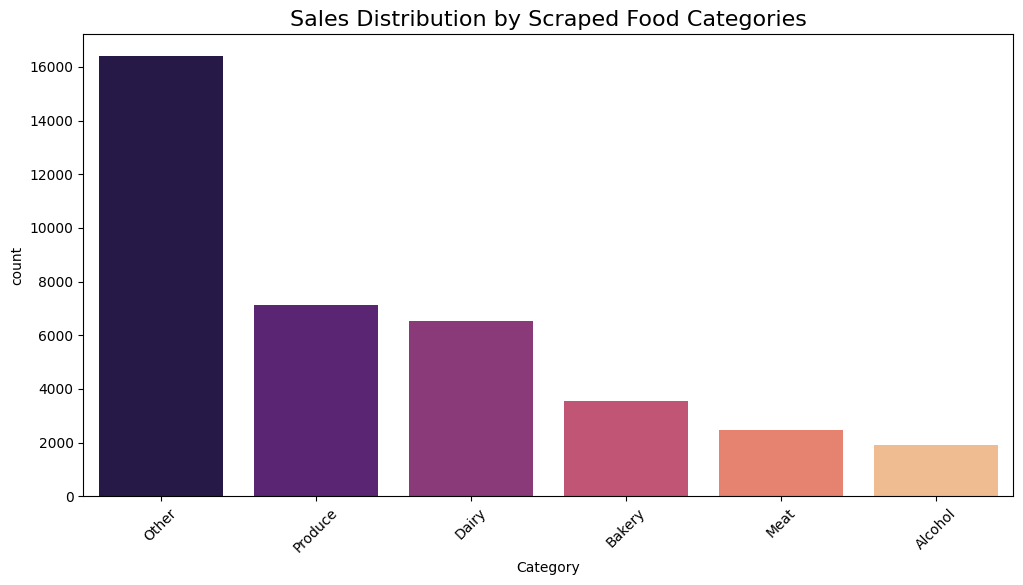

/var/folders/n1/1htyp2cs78s8jn3lcwmplmcm0000gn/T/ipykernel_27333/1853772576.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_basket, x='Is_Weekend', y='itemDescription', palette='coolwarm')


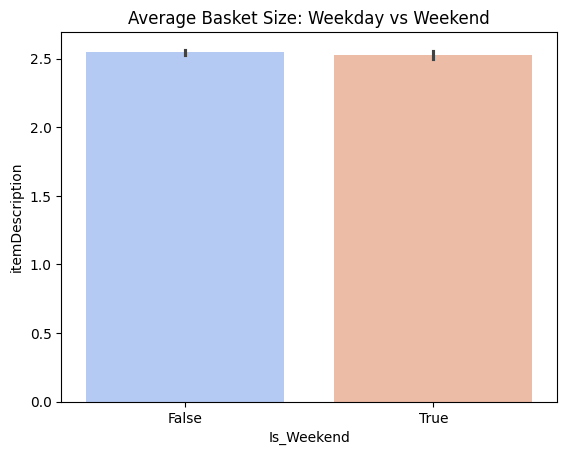

In [29]:
# CELL 5: RESULTS VISUALIZATION
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Category', palette='magma', order=df['Category'].value_counts().index)
plt.title('Sales Distribution by Scraped Food Categories', fontsize=16)
plt.xticks(rotation=45)
plt.show()

# Seasonality Check: Weekday vs Weekend
avg_basket = df.groupby(['Member_number', 'Date', 'Is_Weekend'])['itemDescription'].count().reset_index()
sns.barplot(data=avg_basket, x='Is_Weekend', y='itemDescription', palette='coolwarm')
plt.title('Average Basket Size: Weekday vs Weekend')
plt.show()